# Fly Chess (Colab): grafting a cortex onto the frozen MaleCNS connectome

Standalone version of `fly-chess.ipynb` from the `fly-heaven` project — no local repo needed.
Everything downloads directly from the public MaleCNS v1.0 source (HHMI Janelia + Google Research,
CC BY 4.0), the same data [flychess-hq](https://flychess-hq.vercel.app/) uses.

**The idea.** flychess-hq plays out every legal move, injects each resulting board into 8,865
sensory neurons of the frozen connectome, reads 2,129 descending/motor neurons, and ranks moves
with a **linear** map — no engine ranks the moves, and it plays weakly because it only looks one
move ahead and sits on wiring that was never shaped for chess. This notebook grafts a small
**trainable cortex** onto the same frozen wiring instead: it may only *see* the board by injecting
current into fly sensory neurons, and only *act* by injecting current into fly premotor neurons —
the move is always read out of the fly's own descending/motor population. Controls (§3) measure how
much of any strength gain is the fly versus the graft.

**Before running:** `Runtime → Change runtime type → T4 GPU` (or better). A GPU is required in
practice — the connectome simulation is a 166,606-neuron sparse network per step; CPU is unusably
slow.

**Runtime limits.** Colab's free tier disconnects after a few hours or after ~90 minutes idle,
which will kill a `MODE="full"` run partway through. Training checkpoints every few minutes and
resumes automatically (§2.1), and §0.1 below can optionally save all downloads/checkpoints to
Google Drive so a disconnect only costs the time since the last checkpoint, not the whole run.


## 0 · Setup


In [1]:
!pip install -q python-chess zstandard scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 58.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import chess
import hashlib
import json
import math
import os
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import zstandard
from scipy.sparse import load_npz

# Optional: mount Google Drive so downloads and checkpoints survive a runtime reset.
# Set True, re-run this cell, and approve the access prompt.
USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/fly-chess")
else:
    ROOT = Path("/content/fly-chess")

DATA = ROOT / "data"
RAW = DATA / "malecns-v1.0"
CHESS_DATA = DATA / "fly-chess"
RUNS = ROOT / "runs" / "fly-chess"
for _d in (RAW, CHESS_DATA, RUNS):
    _d.mkdir(parents=True, exist_ok=True)

# "smoke" runs every section in minutes on a slice of data, to check the notebook end to end.
# "full" uses the multi-hour budget described in the text. In Colab, just edit this line and
# re-run rather than setting an environment variable (there's no separate process to launch it into).
MODE = os.environ.get("FLY_CHESS_MODE", "smoke")
assert MODE in ("smoke", "full")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    print("WARNING: no GPU. Runtime -> Change runtime type -> GPU, then Runtime -> Restart session.")
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)


def sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while block := handle.read(8 * 1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


def sh(*args, cwd=ROOT):
    args = [str(a) for a in args]
    print("$", " ".join(args), flush=True)
    with subprocess.Popen(args, cwd=cwd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True) as process:
        for line in process.stdout:
            print(line, end="", flush=True)
    if process.returncode:
        raise subprocess.CalledProcessError(process.returncode, args)


INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.edgecolor": AXIS,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2, "legend.frameon": False,
    "lines.linewidth": 2, "figure.dpi": 110,
})
print(f"mode={MODE}  device={DEVICE}  torch={torch.__version__}  python-chess={chess.__version__}")


mode=smoke  device=cuda  torch=2.11.0+cu128  python-chess=1.11.2


## 0.1 · Data

Three things are pulled in, each cached under `data/fly-chess/` and skipped on later runs:

1. **The MaleCNS connectome graph** — downloaded directly from the public source and built into
   a sparse graph the same way the `fly-heaven` repo's `experiments/fruitless` project does:
   neurons with a non-empty, non-`tbc` `superclass`; signs from `consensus_nt` (acetylcholine
   +1, GABA/glutamate −1, else 0); edges filtered batch-by-batch from a 1 GB Arrow file. No
   connection-weight cutoff at this stage (§1 applies its own for the GPU).
2. **Labelled positions**, streamed from the [Lichess evals dump](https://database.lichess.org/#evals)
   (22 GB compressed) without ever downloading the whole file — the notebook reads the zstd stream
   line by line and stops once it has enough. Each line gives a FEN, a best move (the top PV of its
   deepest search) and a centipawn/mate score, which becomes the value target via Lichess's own
   win% formula.
3. **Held-out puzzles**, similarly streamed from the [Lichess puzzle dump](https://database.lichess.org/#puzzles).
4. **Stockfish** (for training-time labels — already baked into the eval dump, so not needed there —
   and for the opponent/metric in §5), the official Linux x86-64 build, checksum-pinned on first
   download.

`MODE="smoke"` takes a small, fast slice of each so the whole notebook runs in minutes; `MODE="full"`
takes the budget described in §0.


In [3]:
def stream_zst_lines(url):
    """Yields raw lines from a remote .zst file without downloading it whole."""
    dctx = zstandard.ZstdDecompressor()
    with urllib.request.urlopen(url) as response, dctx.stream_reader(response) as reader:
        buffer = b""
        while True:
            chunk = reader.read(1 << 20)
            if not chunk:
                break
            buffer += chunk
            *lines, buffer = buffer.split(b"\n")
            yield from lines
        if buffer:
            yield buffer


### Positions from the Lichess eval dump

Kept only if the deepest recorded search reached `MIN_DEPTH`, to keep the labels usable. The label
move is the first move of that search's best line; the value target is the corresponding win
probability, from the side to move's perspective, via Lichess's own cp→win% curve (`cp2winrate`
below; mate scores map to 0/1).


In [4]:
EVAL_URL = "https://database.lichess.org/lichess_db_eval.jsonl.zst"
N_POSITIONS = 20_000 if MODE == "smoke" else 1_000_000
MIN_DEPTH = 10 if MODE == "smoke" else 14

positions_path = CHESS_DATA / f"positions-{MODE}.npz"


def cp2winrate(cp):
    # https://lichess.org/page/accuracy — win% from the mover's own perspective.
    return 2.0 / (1.0 + math.exp(-0.00368208 * cp)) - 1.0


if not positions_path.exists():
    fens, moves, values = [], [], []
    seen = set()
    started = time.perf_counter()
    gen = stream_zst_lines(EVAL_URL)
    try:
        for raw in gen:
            if not raw:
                continue
            row = json.loads(raw)
            fen = row["fen"]
            if fen in seen:
                continue
            best = max(row["evals"], key=lambda e: e["depth"])
            if best["depth"] < MIN_DEPTH:
                continue
            pv = best["pvs"][0]
            move_uci = pv["line"].split()[0]
            if "mate" in pv:
                value = 1.0 if pv["mate"] > 0 else 0.0
            else:
                value = (cp2winrate(pv["cp"]) + 1.0) / 2.0
            seen.add(fen)
            fens.append(fen)
            moves.append(move_uci)
            values.append(value)
            if len(fens) >= N_POSITIONS:
                break
            if len(fens) % 50_000 == 0:
                rate = len(fens) / (time.perf_counter() - started)
                print(f"  {len(fens):>9,} / {N_POSITIONS:,}  ({rate:,.0f}/s)", flush=True)
    finally:
        gen.close()
    np.savez_compressed(positions_path, fen=np.array(fens), move=np.array(moves), value=np.array(values, np.float32))
    print(f"{len(fens):,} positions in {time.perf_counter() - started:.0f} s -> {positions_path}")

positions = np.load(positions_path, allow_pickle=False)
fens, labels_uci, values = positions["fen"], positions["move"], positions["value"]
print(f"{len(fens):,} labelled positions loaded")

# Deterministic 95/5 split by a hash of the FEN, so train/held-out never depends on file order.
split_key = np.array([int(hashlib.sha1(f.encode()).hexdigest(), 16) % 100 for f in fens])
train_mask = split_key < 95
print(f"train {train_mask.sum():,}  held-out {(~train_mask).sum():,}")


20,000 positions in 3 s -> /content/fly-chess/data/fly-chess/positions-smoke.npz
20,000 labelled positions loaded
train 18,975  held-out 1,025


In [5]:
PUZZLE_URL = "https://database.lichess.org/lichess_db_puzzle.csv.zst"
N_PUZZLES = 500 if MODE == "smoke" else 5_000
puzzles_path = CHESS_DATA / f"puzzles-{MODE}.csv"

if not puzzles_path.exists():
    import csv
    import io

    gen = stream_zst_lines(PUZZLE_URL)
    rows = []
    try:
        header = next(gen).decode()
        for raw in gen:
            rows.append(raw.decode())
            if len(rows) >= N_PUZZLES:
                break
    finally:
        gen.close()
    puzzles_path.write_text(header + "\n" + "\n".join(rows) + "\n")

puzzles = pd.read_csv(puzzles_path)
print(f"{len(puzzles):,} puzzles, rating {puzzles['Rating'].min()}-{puzzles['Rating'].max()}")


500 puzzles, rating 399-3062


In [6]:
import tarfile

STOCKFISH_DIR = CHESS_DATA / "stockfish"
STOCKFISH_BIN = STOCKFISH_DIR / "stockfish"
STOCKFISH_URL = "https://github.com/official-stockfish/Stockfish/releases/download/sf_19/stockfish-linux-x86-64-universal.tar.gz"
STOCKFISH_LOCK = STOCKFISH_DIR / "source.lock.json"

STOCKFISH_DIR.mkdir(parents=True, exist_ok=True)
if not STOCKFISH_BIN.exists():
    archive = STOCKFISH_DIR / "stockfish.tar.gz"
    print(f"Downloading {STOCKFISH_URL}", flush=True)
    urllib.request.urlretrieve(STOCKFISH_URL, archive)
    digest = sha256(archive)
    # The release also ships its own source tree, which includes docs like wiki/Stockfish-FAQ.md —
    # match the exact binary name (the asset's own filename, minus .tar.gz), not just a substring.
    expected_name = Path(STOCKFISH_URL).name.removesuffix(".tar.gz")
    with tarfile.open(archive) as tar:
        member = next(m for m in tar.getmembers() if m.isfile() and Path(m.name).name == expected_name)
        member.name = "stockfish"
        tar.extract(member, STOCKFISH_DIR, filter="data")
    archive.unlink()
    STOCKFISH_BIN.chmod(0o755)
    STOCKFISH_LOCK.write_text(json.dumps({"url": STOCKFISH_URL, "sha256": digest}, indent=2))
    print("pinned Stockfish sha256", digest)
else:
    pin = json.loads(STOCKFISH_LOCK.read_text())["sha256"]
    # Re-derive from the extracted binary is not meaningful (tar strips metadata); trust the pin
    # recorded at download time and only assert the binary still runs.
    print("Stockfish already present, pinned sha256", pin)

out = subprocess.run([str(STOCKFISH_BIN), "quit"], input="uci\n", capture_output=True, text=True, timeout=10)
assert "Stockfish" in out.stdout, out.stdout
print(out.stdout.splitlines()[0])


pinned Stockfish sha256 9defc0d4e55d49c65a6d042f3e571a39fcea499ade6dbe741b53b8c65e03611f
Stockfish 19 by the Stockfish developers (see AUTHORS file)


## 0.2 · Board and move encoding

Every board is seen from the side-to-move's perspective (mirrored vertically when Black is to
move, per the usual convention), as **780 binary features**: 12 piece-type×colour planes over 64
squares, 4 castling rights, and 8 en-passant files. Moves are **from-square × to-square** in that
same mirrored frame (4,096 classes); a chosen promotion always queens, which loses only the rare
under-promotion tactic.


In [7]:
PIECE_INDEX = {chess.PAWN: 0, chess.KNIGHT: 1, chess.BISHOP: 2, chess.ROOK: 3, chess.QUEEN: 4, chess.KING: 5}
N_FEATURES = 780
N_MOVES = 4096


def perspective_square(square, us):
    return square if us == chess.WHITE else chess.square_mirror(square)


def encode_board(board):
    x = np.zeros(N_FEATURES, dtype=np.float32)
    us, them = board.turn, not board.turn
    for square, piece in board.piece_map().items():
        sq = perspective_square(square, us)
        offset = 0 if piece.color == us else 6
        x[(offset + PIECE_INDEX[piece.piece_type]) * 64 + sq] = 1.0
    base = 768
    x[base + 0] = board.has_kingside_castling_rights(us)
    x[base + 1] = board.has_queenside_castling_rights(us)
    x[base + 2] = board.has_kingside_castling_rights(them)
    x[base + 3] = board.has_queenside_castling_rights(them)
    if board.ep_square is not None:
        ep = perspective_square(board.ep_square, us)
        x[base + 4 + chess.square_file(ep)] = 1.0
    return x


def move_index(move, us):
    frm = perspective_square(move.from_square, us)
    to = perspective_square(move.to_square, us)
    return frm * 64 + to


def legal_move_table(board):
    """{move_index: [legal chess.Move, ...]} for every legal move, mirrored to the mover's frame."""
    us = board.turn
    table = {}
    for move in board.legal_moves:
        table.setdefault(move_index(move, us), []).append(move)
    return table


def index_to_move(idx, board):
    """The model's chosen class -> a concrete legal move (auto-queen among ties)."""
    table = legal_move_table(board)
    candidates = table[idx]
    if len(candidates) == 1:
        return candidates[0]
    queen = [m for m in candidates if m.promotion == chess.QUEEN]
    return queen[0] if queen else candidates[0]


# Round-trip check: every legal move in a sample of positions must be recoverable.
_rng = np.random.RandomState(0)
_checked = 0
for fen in fens[_rng.randint(0, len(fens), size=min(1000, len(fens)))]:
    board = chess.Board(fen)
    table = legal_move_table(board)
    for idx in table:
        recovered = index_to_move(idx, board)
        assert recovered in board.legal_moves
        _checked += 1
assert _checked > 0
print(f"move encoding round-trips on {_checked:,} legal moves across 1,000 positions")


move encoding round-trips on 27,957 legal moves across 1,000 positions


## 1 · The frozen fly

**Design.** The spiking model used in `fly-heaven.ipynb` is exact but not differentiable and runs
about 18× slower than real time for one board — useless for gradient training. Here the same wiring
and synapse signs drive a batched **graded-rate** model instead:

```
r ← (1-α)·r + α·clamp(g · Wᵀ(sign⊙r) + I, 0, 1)
```

`W` is the fruitless project's prepared CSR graph (`experiments/fruitless/experiment/prepare.py`),
thresholded to a minimum synapse count to fit the GPU, and each target neuron's incoming weights
are pre-normalised to sum to 1 in magnitude so `g` has a comparable meaning everywhere.

Two populations are fixed by measurement, not by hand: **sensory** = `cb_sensory`+`ol_sensory`
(10,966 neurons — flychess-hq's site reports 8,865, likely a narrower list; this is measured on the
data actually in hand) and **M** = `descending_neuron`+`cb_motor`+`vnc_motor` (2,129 — an exact
match to flychess-hq's reported 2,129). A **relay** set (a thalamus analogue) and a **premotor**
set `P` are chosen below by measurement, not guessed.


In [8]:
GRAPH_DIR = CHESS_DATA / "connectome"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_PATH = GRAPH_DIR / "full-graph.npz"
NODES_PATH = GRAPH_DIR / "full-nodes.npz"

# Same public MaleCNS v1.0 source fly-heaven's fruitless and fly-wirehead projects pin (CC BY 4.0).
MALECNS_SOURCES = {
    "annotations.feather": {
        "url": "https://storage.googleapis.com/flyem-male-cns/v1.0/connectome-data/flat-connectome/body-annotations-male-cns-v1.0-minconf-0.5.feather",
        "bytes": 14483314,
        "sha256": "2177e246113e4cfbf1e7772ec37c6da1955ff22e8063d0b1f833101f99a9a3b2",
    },
    "neurotransmitters.feather": {
        "url": "https://storage.googleapis.com/flyem-male-cns/v1.0/connectome-data/flat-connectome/body-neurotransmitters-male-cns-v1.0.feather",
        "bytes": 43282834,
        "sha256": "95c9289220663abeb3409f3ad9e5a7f8a53f8093f5139d15502cd08da8879621",
    },
    "edges.feather": {
        "url": "https://storage.googleapis.com/flyem-male-cns/v1.0/connectome-data/flat-connectome/connectome-weights-male-cns-v1.0-minconf-0.5.feather",
        "bytes": 1051241946,
        "sha256": "e35da783d1c686b2b58b3b87cd6a403ae43bfcfba8bff28e08ef752c1a56afc1",
    },
}
for name, info in MALECNS_SOURCES.items():
    path = RAW / name
    if not path.exists():
        print(f"Downloading {name} ({info['bytes'] / 1e6:,.0f} MB)…", flush=True)
        partial = path.with_suffix(".partial")
        urllib.request.urlretrieve(info["url"], partial)
        partial.replace(path)
    digest = sha256(path)
    assert digest == info["sha256"], f"Checksum mismatch: {name}"
    print(f"verified  {name:27s} {path.stat().st_size / 1e6:>8,.1f} MB")

if not NODES_PATH.exists():
    import pyarrow as pa
    import pyarrow.compute as pc
    import pyarrow.feather as feather
    from scipy.sparse import csr_matrix, save_npz

    print("Building the connectome graph (fruitless's own recipe)…", flush=True)
    started = time.perf_counter()
    rows = feather.read_table(RAW / "annotations.feather").to_pylist()
    rows = sorted((r for r in rows if r["superclass"] and "tbc" not in r["superclass"]), key=lambda r: r["bodyId"])
    ids = np.array([r["bodyId"] for r in rows], dtype=np.int64)

    nt_table = feather.read_table(RAW / "neurotransmitters.feather", columns=["body", "consensus_nt"])
    nt_table = nt_table.filter(pc.is_in(nt_table["body"], pa.array(ids)))
    nts = dict(zip(nt_table["body"].to_pylist(), nt_table["consensus_nt"].to_pylist()))
    # Assumed fast signs, not measured receptor-specific physiology. Others get zero fast weight.
    signs = np.array([{"acetylcholine": 1, "gaba": -1, "glutamate": -1}.get(nts.get(int(i)), 0) for i in ids], dtype=np.int8)

    source = pa.memory_map(str(RAW / "edges.feather"))
    reader = pa.ipc.open_file(source)
    pre, post, weight = [], [], []
    for b in range(reader.num_record_batches):
        t = pa.Table.from_batches([reader.get_batch(b)])
        t = t.filter(pc.and_(pc.is_in(t["body_pre"], pa.array(ids)), pc.is_in(t["body_post"], pa.array(ids))))
        pre.append(np.searchsorted(ids, t["body_pre"].to_numpy()).astype(np.int32))
        post.append(np.searchsorted(ids, t["body_post"].to_numpy()).astype(np.int32))
        weight.append(t["weight"].to_numpy().astype(np.float32))
        if b % 400 == 0:
            print(f"  edge batch {b + 1}/{reader.num_record_batches}", flush=True)
    pre, post, weight = map(np.concatenate, (pre, post, weight))
    graph = csr_matrix((weight, (pre, post)), shape=(len(ids), len(ids)))
    graph.sort_indices()
    save_npz(GRAPH_PATH, graph)
    np.savez(NODES_PATH, ids=ids, signs=signs)
    print(f"{len(ids):,} neurons, {graph.nnz:,} edges built in {time.perf_counter() - started:.0f} s")

nodes = np.load(NODES_PATH)
ids, base_signs = nodes["ids"], nodes["signs"]
W = load_npz(GRAPH_PATH)  # CSR, rows = presynaptic, values = synapse counts
N_NEURONS = W.shape[0]
assert (N_NEURONS, W.nnz) == (166_606, 25_574_615), "Graph differs from the reference build"

ann = (pd.read_feather(RAW / "annotations.feather", columns=["bodyId", "superclass", "class", "type"])
       .set_index("bodyId").reindex(ids))

SENSORY_IDX = np.nonzero(ann["superclass"].isin(["cb_sensory", "ol_sensory"]).values)[0]
MOTOR_IDX = np.nonzero(ann["superclass"].isin(["descending_neuron", "cb_motor", "vnc_motor"]).values)[0]
assert len(SENSORY_IDX) == 10_966 and len(MOTOR_IDX) == 2_129
print(f"sensory {len(SENSORY_IDX):,}  ·  DN+motor {len(MOTOR_IDX):,}  ·  total {N_NEURONS:,}")


verified  annotations.feather             14.5 MB
verified  neurotransmitters.feather       43.3 MB
verified  edges.feather                1,051.2 MB
Building the connectome graph (fruitless's own recipe)…
  edge batch 1/2318
  edge batch 401/2318
  edge batch 801/2318
  edge batch 1201/2318
  edge batch 1601/2318
  edge batch 2001/2318
166,606 neurons, 25,574,615 edges built in 84 s
sensory 10,966  ·  DN+motor 2,129  ·  total 166,606


In [9]:
EDGE_MIN_SYNAPSES = 3  # picked below in the Phase-0 benchmark; kept ≥ here so later cells still run standalone


def build_signed_transpose(W, signs, min_synapses):
    """Wt[post, pre] = sign(pre) * synapse_count, thresholded and row-normalised (row = post)."""
    keep = W.data >= min_synapses
    pre = np.repeat(np.arange(W.shape[0]), np.diff(W.indptr))[keep]
    post = W.indices[keep]
    weight = (W.data[keep] * signs[pre]).astype(np.float32)
    row_norm = np.bincount(post, weights=np.abs(weight), minlength=W.shape[0])
    row_norm = np.maximum(row_norm, 1.0)
    weight = (weight / row_norm[post]).astype(np.float32)
    indices = torch.tensor(np.stack([post, pre]), dtype=torch.long)
    values = torch.tensor(weight)
    return torch.sparse_coo_tensor(indices, values, (W.shape[0], W.shape[0])).coalesce(), int(keep.sum())


Wt, n_edges_kept = build_signed_transpose(W, base_signs, EDGE_MIN_SYNAPSES)
Wt = Wt.to(DEVICE)
print(f"kept {n_edges_kept:,} / {W.nnz:,} edges at ≥{EDGE_MIN_SYNAPSES} synapses "
      f"({n_edges_kept / W.nnz:.0%}), {W.data[W.data >= EDGE_MIN_SYNAPSES].sum() / W.data.sum():.0%} of synapse mass")


class FlyBrain(nn.Module):
    """Frozen, batched, differentiable graded-rate model of the MaleCNS connectome."""

    def __init__(self, Wt, gain, alpha):
        super().__init__()
        self.register_buffer("Wt", Wt, persistent=False)
        self.n = Wt.shape[0]
        self.gain = gain
        self.alpha = alpha

    def step(self, r, current):
        total_input = torch.sparse.mm(self.Wt, r)
        target = torch.clamp(self.gain * total_input + current, 0.0, 1.0)
        return (1 - self.alpha) * r + self.alpha * target

    def run(self, r0, current, steps):
        r = r0
        for _ in range(steps):
            r = self.step(r, current)
        return r

    def run_clamped(self, r0, current, active_mask, steps):
        """Only `active_mask` neurons update; everyone else is held at r0 (§ act-phase)."""
        r = r0
        frozen = r0
        mask = active_mask.view(-1, 1)
        for _ in range(steps):
            r = torch.where(mask, self.step(r, current), frozen)
        return r


/tmp/ipykernel_3593/249033171.py:15: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_coo_tensor(indices, values, (W.shape[0], W.shape[0])).coalesce(), int(keep.sum())


kept 10,517,265 / 25,574,615 edges at ≥3 synapses (41%), 84% of synapse mass


In [10]:
def build_injection_map(sensory_idx, n_features, seed=0):
    """A fixed, disjoint feature -> sensory-neuron-group assignment (~14 neurons/feature)."""
    rng = np.random.RandomState(seed)
    order = rng.permutation(sensory_idx)
    groups = np.array_split(order, n_features)
    rows = np.concatenate(groups)
    cols = np.concatenate([np.full(len(g), i) for i, g in enumerate(groups)])
    indices = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    values = torch.ones(len(rows))
    return torch.sparse_coo_tensor(indices, values, (N_NEURONS, n_features)).coalesce().to(DEVICE)


INJECT_MAP = build_injection_map(SENSORY_IDX, N_FEATURES)
INJECT_AMPLITUDE = 1.0


def sensory_current(features_b_f):
    """(B, 780) board features -> (n, B) injected current."""
    return INJECT_AMPLITUDE * torch.sparse.mm(INJECT_MAP, features_b_f.t())


def empty_cache():
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


def perceive_chunked(brain_, features_np, T_p, batch=128, keep_idx=None):
    """Runs perception in GPU-sized chunks and returns a CPU array — the (n, N) state for N boards
    at once does not fit in 6 GB much past a few hundred boards. `keep_idx` restricts the returned
    rows (e.g. to a relay candidate) to save host memory too."""
    chunks = []
    for start in range(0, len(features_np), batch):
        feats = torch.tensor(features_np[start:start + batch], device=DEVICE)
        with torch.no_grad():
            r = brain_.run(torch.zeros(brain_.n, feats.shape[0], device=DEVICE), sensory_current(feats), T_p)
        chunks.append((r if keep_idx is None else r[keep_idx]).cpu().numpy())
        del feats, r
    empty_cache()
    return np.concatenate(chunks, axis=1)


T_P_GRID = [10, 20] if MODE == "smoke" else [15, 25, 40]
BENCH_BATCH = 64
sample_fens = fens[np.random.RandomState(1).randint(0, len(fens), size=BENCH_BATCH)]
sample_features = torch.tensor(np.stack([encode_board(chess.Board(f)) for f in sample_fens]), device=DEVICE)

brain = FlyBrain(Wt, gain=2.0, alpha=0.5)
r0 = torch.zeros(N_NEURONS, BENCH_BATCH, device=DEVICE)
current = sensory_current(sample_features)
torch.cuda.synchronize() if DEVICE.type == "cuda" else None
begin = time.perf_counter()
with torch.no_grad():
    r = brain.run(r0, current, T_P_GRID[-1])
torch.cuda.synchronize() if DEVICE.type == "cuda" else None
elapsed = time.perf_counter() - begin
print(f"{T_P_GRID[-1]} perception steps, batch {BENCH_BATCH}: {elapsed:.2f} s "
      f"({elapsed / T_P_GRID[-1] * 1000:.1f} ms/step, {elapsed / T_P_GRID[-1] / BENCH_BATCH * 1e6:.0f} µs/step/board)")
print(f"activity after {T_P_GRID[-1]} steps: {(r > 0.05).float().mean().item():.1%} of neurons active")
del r0, r, current
empty_cache()


20 perception steps, batch 64: 0.98 s (49.0 ms/step, 766 µs/step/board)
activity after 20 steps: 4.3% of neurons active


In [11]:
GAIN_GRID = [1.5, 3.0] if MODE == "smoke" else [1.5, 2.5, 4.0]
ALPHA_GRID = [0.5] if MODE == "smoke" else [0.3, 0.6, 1.0]

two_fens = fens[np.random.RandomState(2).randint(0, len(fens), size=2)]
two_features = torch.tensor(np.stack([encode_board(chess.Board(f)) for f in two_fens]), device=DEVICE)
two_current = sensory_current(two_features)

calibration_rows = []
for g in GAIN_GRID:
    for a in ALPHA_GRID:
        for T_p in T_P_GRID:
            probe = FlyBrain(Wt, gain=g, alpha=a)
            with torch.no_grad():
                r = probe.run(torch.zeros(N_NEURONS, 2, device=DEVICE), two_current, T_p)
            active = (r > 0.05).float().mean().item()
            distance = (r[:, 0] - r[:, 1]).norm().item() / (r.norm(dim=0).mean().item() + 1e-8)
            calibration_rows.append({"gain": g, "alpha": a, "T_p": T_p, "active_frac": active, "board_distance": distance})

calibration = pd.DataFrame(calibration_rows)
feasible = calibration[calibration["active_frac"].between(0.01, 0.30)]
best = (feasible if len(feasible) else calibration).sort_values("board_distance", ascending=False).iloc[0]
GAIN, ALPHA, T_P = float(best.gain), float(best.alpha), int(best.T_p)
print(calibration.sort_values("board_distance", ascending=False).head(8).to_string(index=False))
print(f"\npicked gain={GAIN} alpha={ALPHA} T_p={T_P}  "
      f"(active {best.active_frac:.1%}, board distance {best.board_distance:.2f})")
brain = FlyBrain(Wt, gain=GAIN, alpha=ALPHA)
del two_current, two_features
empty_cache()


 gain  alpha  T_p  active_frac  board_distance
  1.5    0.5   10     0.004496        1.399512
  1.5    0.5   20     0.007416        1.387808
  3.0    0.5   10     0.043540        1.145664
  3.0    0.5   20     0.062591        0.641232

picked gain=3.0 alpha=0.5 T_p=10  (active 4.4%, board distance 1.15)


### Choosing the relay set by measurement

A relay candidate is useful only if the board is actually legible from it. For each candidate
population, a ridge regression is fit from that population's rate vector back to the 780 board
features on a few thousand boards; the held-out R² says how much of the board survived perception.
Candidates: 1-hop and 2-hop successors of the sensory neurons (found by sparse matrix-vector
propagation through `W`, not a hand list), the mushroom-body input/output cells (`class` Kenyon_Cell
+ MBON), and the visual-projection population. The best-scoring candidate at ≤8,000 neurons wins.


In [12]:
def hop_mask(seed_idx, W, exclude=None):
    v = np.zeros(W.shape[0], dtype=np.float32)
    v[seed_idx] = 1.0
    reached = (v @ W) > 0
    if exclude is not None:
        reached &= ~exclude
    return reached


hop1 = hop_mask(SENSORY_IDX, W)
hop2 = hop_mask(np.nonzero(hop1)[0], W, exclude=hop1 | np.isin(np.arange(N_NEURONS), SENSORY_IDX))
kc_mbon = ann["class"].isin(["Kenyon_Cell", "MBON"]).values
visual_proj = (ann["superclass"] == "visual_projection").values

RELAY_CANDIDATES = {
    "1-hop from sensory": np.nonzero(hop1)[0],
    "2-hop from sensory": np.nonzero(hop2)[0],
    "Kenyon+MBON": np.nonzero(kc_mbon)[0],
    "visual_projection": np.nonzero(visual_proj)[0],
}
RELAY_MAX = 8000
# The full (n, N_PROBE) state doesn't fit in 6 GB past a few hundred boards, so §1's benchmark
# chunk size is reused here — perceive_chunked runs one chunk at a time and returns a CPU array.
N_PROBE = 300 if MODE == "smoke" else 4000
PROBE_BATCH = 128

probe_fens = fens[np.random.RandomState(3).randint(0, len(fens), size=N_PROBE)]
probe_features = np.stack([encode_board(chess.Board(f)) for f in probe_fens])
probe_state = perceive_chunked(brain, probe_features, T_P, batch=PROBE_BATCH)

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

relay_scores = {}
for name, idx in RELAY_CANDIDATES.items():
    pick = idx if len(idx) <= RELAY_MAX else np.random.RandomState(4).choice(idx, RELAY_MAX, replace=False)
    Xtr, Xte, Ytr, Yte = train_test_split(probe_state[pick].T, probe_features, test_size=0.2, random_state=0)
    model = Ridge(alpha=1.0).fit(Xtr, Ytr)
    r2 = model.score(Xte, Yte)
    relay_scores[name] = (r2, len(pick))
    print(f"{name:20s}  n={len(pick):>6,}  held-out R²={r2:.3f}")

RELAY_NAME = max(relay_scores, key=lambda k: relay_scores[k][0])
RELAY_IDX = (RELAY_CANDIDATES[RELAY_NAME] if len(RELAY_CANDIDATES[RELAY_NAME]) <= RELAY_MAX
             else np.random.RandomState(4).choice(RELAY_CANDIDATES[RELAY_NAME], RELAY_MAX, replace=False))
print(f"\nrelay = {RELAY_NAME}, {len(RELAY_IDX):,} neurons, R²={relay_scores[RELAY_NAME][0]:.3f}")
del probe_state
empty_cache()


1-hop from sensory    n= 8,000  held-out R²=0.535
2-hop from sensory    n= 8,000  held-out R²=0.436
Kenyon+MBON           n= 4,161  held-out R²=0.427
visual_projection     n= 8,000  held-out R²=0.387

relay = 1-hop from sensory, 8,000 neurons, R²=0.535


In [13]:
P_SIZE = 1000 if MODE == "smoke" else 4000

motor_indicator = np.zeros(N_NEURONS, dtype=np.float32)
motor_indicator[MOTOR_IDX] = 1.0
synapses_onto_motor = W @ motor_indicator  # row i = total synapses from neuron i onto M
PREMOTOR_IDX = np.argsort(-synapses_onto_motor)[:P_SIZE]
PREMOTOR_IDX = PREMOTOR_IDX[synapses_onto_motor[PREMOTOR_IDX] > 0]
print(f"premotor P: {len(PREMOTOR_IDX):,} central neurons, "
      f"{synapses_onto_motor[PREMOTOR_IDX].min():.0f}-{synapses_onto_motor[PREMOTOR_IDX].max():.0f} synapses onto M each")

ACTIVE_MASK = torch.zeros(N_NEURONS, dtype=torch.bool, device=DEVICE)
ACTIVE_MASK[PREMOTOR_IDX] = True
ACTIVE_MASK[MOTOR_IDX] = True
T_A = 3


premotor P: 1,000 central neurons, 1216-9677 synapses onto M each


In [14]:
N_PROBES = 64 if MODE == "smoke" else 256
probe_currents = torch.zeros(N_NEURONS, N_PROBES, device=DEVICE)
probe_idx = torch.tensor(np.random.RandomState(5).choice(PREMOTOR_IDX, size=(N_PROBES, min(50, len(PREMOTOR_IDX)))), device=DEVICE)
probe_amp = torch.randn(N_PROBES, probe_idx.shape[1], device=DEVICE)
probe_currents.scatter_(0, probe_idx.t(), probe_amp.t())

with torch.no_grad():
    r_state = brain.run(torch.zeros(N_NEURONS, N_PROBES, device=DEVICE),
                         sensory_current(torch.tensor(probe_features[:N_PROBES], device=DEVICE)), T_P)
    m_out = brain.run_clamped(r_state, probe_currents, ACTIVE_MASK, T_A)[MOTOR_IDX].cpu().numpy()

singular = np.linalg.svd(m_out - m_out.mean(1, keepdims=True), compute_uv=False)
eff_rank = int((singular > 0.01 * singular[0]).sum())
print(f"probe->M effective rank ≈ {eff_rank} / {min(N_PROBES, len(MOTOR_IDX))} "
      f"(top singular values: {np.round(singular[:5], 2)})")
if eff_rank < 8:
    print("WARNING: low controllability — consider a larger P or more T_a steps before training.")
del probe_currents, probe_idx, probe_amp, r_state
empty_cache()


probe->M effective rank ≈ 63 / 64 (top singular values: [6.56 3.21 2.77 2.62 2.51])


### LIF cross-check — not included here

`fly-heaven.ipynb`'s spiking cross-check calls `experiments/fruitless`'s own Numba kernel directly, which isn't available standalone. Skipped in this Colab version; see the main repo if you want that comparison.


## 2 · The cortex graft

**Design.** A small Perceiver-style network: a fixed number of learned "column" latents
cross-attend to the relay population's rates (each relay neuron is a token: a learned embedding for
that specific neuron, scaled by its rate), then refine themselves over a few self-attention
iterations — the "deliberation" a linear readout can't do. A second cross-attention, from one
learned query per premotor neuron back onto the latents, produces the top-down current injected
into `P`. Everything upstream of the fly (encoding) and downstream of it (the two decoder heads) is
free-form; **only the path between them must go through the fly**.

Perception (frozen, no gradient) runs once per board; only the short act-phase (`T_a` steps, gated
to `P∪M`, §1) carries gradient back into the graft — so a full-brain backward pass is never needed.


In [15]:
class CortexGraft(nn.Module):
    def __init__(self, relay_idx, premotor_idx, d_model=64, n_latents=48, n_layers=2, n_heads=4):
        super().__init__()
        self.register_buffer("relay_idx", torch.tensor(relay_idx, dtype=torch.long), persistent=False)
        self.register_buffer("premotor_idx", torch.tensor(premotor_idx, dtype=torch.long), persistent=False)
        n_relay, n_premotor = len(relay_idx), len(premotor_idx)

        self.relay_embed = nn.Embedding(n_relay, d_model)
        self.premotor_query = nn.Embedding(n_premotor, d_model)
        self.latents = nn.Parameter(torch.randn(n_latents, d_model) * 0.02)

        self.encode_in = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.self_layers = nn.ModuleList(
            nn.MultiheadAttention(d_model, n_heads, batch_first=True) for _ in range(n_layers)
        )
        self.norms = nn.ModuleList(nn.LayerNorm(d_model) for _ in range(n_layers + 1))
        self.decode_out = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.current_head = nn.Linear(d_model, 1)

    def forward(self, relay_rate):
        """relay_rate: (B, n_relay) -> premotor current (B, n_premotor)."""
        B = relay_rate.shape[0]
        tokens = self.relay_embed.weight.unsqueeze(0) * relay_rate.unsqueeze(-1)  # (B, n_relay, d)
        latents = self.latents.unsqueeze(0).expand(B, -1, -1)
        latents = self.norms[0](latents + self.encode_in(latents, tokens, tokens)[0])
        for layer, norm in zip(self.self_layers, self.norms[1:]):
            latents = norm(latents + layer(latents, latents, latents)[0])
        queries = self.premotor_query.weight.unsqueeze(0).expand(B, -1, -1)
        out, _ = self.decode_out(queries, latents, latents)
        return self.current_head(out).squeeze(-1)  # (B, n_premotor)


class MoveDecoder(nn.Module):
    """Reads the fly's own DN+motor population; never sees the board or the relay directly."""

    def __init__(self, n_motor, n_moves=N_MOVES, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_motor, hidden), nn.GELU())
        self.policy = nn.Linear(hidden, n_moves)
        self.value = nn.Linear(hidden, 1)

    def forward(self, motor_rate):
        h = self.net(motor_rate)
        return self.policy(h), self.value(h).squeeze(-1)


class FlyChessModel(nn.Module):
    """board -> (fly sense) -> graft -> (fly act) -> policy logits, value. `brain` stays frozen."""

    def __init__(self, brain, relay_idx, premotor_idx, motor_idx, active_mask, T_p, T_a,
                 current_amplitude=2.0, **graft_kw):
        super().__init__()
        self.brain = brain
        self.graft = CortexGraft(relay_idx, premotor_idx, **graft_kw)
        self.decoder = MoveDecoder(len(motor_idx))
        self.register_buffer("relay_idx", torch.tensor(relay_idx, dtype=torch.long), persistent=False)
        self.register_buffer("premotor_idx", torch.tensor(premotor_idx, dtype=torch.long), persistent=False)
        self.register_buffer("motor_idx", torch.tensor(motor_idx, dtype=torch.long), persistent=False)
        self.register_buffer("active_mask", active_mask, persistent=False)
        self.T_p, self.T_a, self.current_amplitude = T_p, T_a, current_amplitude

    def forward(self, features, lesion_relay=False):
        n, B = self.brain.n, features.shape[0]
        with torch.no_grad():
            r_perceived = self.brain.run(torch.zeros(n, B, device=features.device),
                                          sensory_current(features), self.T_p)
        relay_rate = r_perceived[self.relay_idx].t()  # (B, n_relay)
        if lesion_relay:
            relay_rate = torch.zeros_like(relay_rate)  # §3 C3: sever fly->graft, keep everything else
        premotor_current = self.graft(relay_rate) * self.current_amplitude

        current = torch.zeros(n, B, device=features.device)
        current[self.premotor_idx] = premotor_current.t()
        r_final = self.brain.run_clamped(r_perceived, current, self.active_mask, self.T_a)
        motor_rate = r_final[self.motor_idx].t()  # (B, n_motor)
        return self.decoder(motor_rate)


## 2.1 · Training

Cross-entropy on the labelled best move plus BCE on the win-probability target. Perception carries
no gradient (§1), so *backward* only costs `graft` + `decoder` + `T_a`'s short act-phase — but
perception still has to run *forward* every step (it's what the graft sees), and that full-brain
pass is the dominant cost regardless of gradients: ~1.27 s/step measured on an RTX 4050 at this
batch size and `P_SIZE`. Three separate models need it (main, C0, C2 — C1 has no fly and is much
cheaper), so full mode caps training at a fixed step budget rather than a full epoch over the
downloaded positions, to fit inside a few hours total. Checkpoints save periodically so a run can be
killed and resumed.


In [16]:
# The act-phase backward pass keeps T_a full-graph tensors live at once, and the premotor decode
# attends over up to P_SIZE queries — both scale with batch size. 64 was the largest that stayed
# comfortably inside 6 GB in testing; raise it if more GPU memory is available.
BATCH_SIZE = 32 if MODE == "smoke" else 64
EPOCHS = 1
# Measured directly on this GPU (batch 64, P_SIZE 4000, T_p 25): ~1.27 s/step for any model that
# runs the fly (main, C0, C2 all pay this; C1 has no fly and is far cheaper). Three fly-based models
# each doing a full ~14,800-step epoch over 950k positions would be ~15 hours combined — nowhere
# near the "a few hours" budget — so full mode caps steps instead of running a full epoch.
STEPS_PER_EPOCH = 30 if MODE == "smoke" else 2500  # ~0.9h/model for main, C0, C2; ~2.7h combined
CHECKPOINT_EVERY_S = 60 if MODE == "smoke" else 600
# Namespaced by MODE: smoke and full differ in architecture (P_SIZE, relay size, ...), so a full
# run must never try to resume from — or overwrite — a smoke-mode checkpoint or its logs.
CKPT_PATH = RUNS / f"graft-{MODE}.pt"

train_idx = np.nonzero(train_mask)[0]
heldout_idx = np.nonzero(~train_mask)[0]
move_lookup = {}  # cache: fen -> (feature vector, label index, legal move-index set)


def make_batch(idx_batch):
    feats, labels, values_b = [], [], []
    for i in idx_batch:
        fen = str(fens[i])
        board = chess.Board(fen)
        feats.append(encode_board(board))
        labels.append(move_index(chess.Move.from_uci(str(labels_uci[i])), board.turn))
        values_b.append(values[i])
    return (torch.tensor(np.stack(feats), device=DEVICE),
            torch.tensor(labels, device=DEVICE, dtype=torch.long),
            torch.tensor(values_b, device=DEVICE, dtype=torch.float32))


def build_model():
    brain_ = FlyBrain(Wt, gain=GAIN, alpha=ALPHA)
    return FlyChessModel(brain_, RELAY_IDX, PREMOTOR_IDX, MOTOR_IDX, ACTIVE_MASK, T_P, T_A).to(DEVICE)


def n_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate_move_match(model, idx_pool, n=200):
    model.eval()
    sample = np.random.RandomState(0).choice(idx_pool, size=min(n, len(idx_pool)), replace=False)
    correct = 0
    with torch.no_grad():
        for start in range(0, len(sample), BATCH_SIZE):
            batch = sample[start:start + BATCH_SIZE]
            feats, labels, _ = make_batch(batch)
            logits, _ = model(feats)
            correct += (logits.argmax(1) == labels).sum().item()
    model.train()
    return correct / len(sample)


def train(model, resume=True, tag="main", steps_per_epoch=STEPS_PER_EPOCH, checkpoint_path=CKPT_PATH):
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
    start_step = 0
    log_rows = []
    if resume and checkpoint_path.exists():
        state = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        start_step = state["step"]
        print(f"resumed {tag} from step {start_step}")

    n_steps = steps_per_epoch or math.ceil(len(train_idx) / BATCH_SIZE)
    last_checkpoint = time.perf_counter()
    started = time.perf_counter()
    rng = np.random.RandomState(SEED)
    for step in range(start_step, n_steps):
        batch = rng.choice(train_idx, size=BATCH_SIZE, replace=False)
        feats, labels, target_value = make_batch(batch)
        logits, value = model(feats)
        loss_policy = F.cross_entropy(logits, labels)
        loss_value = F.binary_cross_entropy_with_logits(value, target_value)
        loss = loss_policy + loss_value
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % max(1, n_steps // 20) == 0 or step == n_steps - 1:
            acc = evaluate_move_match(model, heldout_idx)
            elapsed = time.perf_counter() - started
            row = {"tag": tag, "step": step, "loss": loss.item(), "loss_policy": loss_policy.item(),
                   "loss_value": loss_value.item(), "heldout_move_match": acc, "elapsed_s": elapsed}
            log_rows.append(row)
            print(f"[{tag}] step {step:>5}/{n_steps}  loss {loss.item():.3f}  "
                  f"held-out match {acc:.1%}  ({elapsed:.0f} s)", flush=True)

        if time.perf_counter() - last_checkpoint > CHECKPOINT_EVERY_S:
            torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "step": step + 1}, checkpoint_path)
            last_checkpoint = time.perf_counter()

    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "step": n_steps}, checkpoint_path)
    log_df = pd.DataFrame(log_rows)
    log_path = RUNS / f"train-{tag}-{MODE}.csv"
    log_df.to_csv(log_path, index=False)
    return log_df


model = build_model()
print(f"{n_trainable(model):,} trainable parameters (graft + decoder)")
train_log = train(model, tag="main")


2,244,290 trainable parameters (graft + decoder)
[main] step     0/30  loss 9.002  held-out match 0.5%  (3 s)
[main] step     1/30  loss 9.009  held-out match 0.5%  (5 s)
[main] step     2/30  loss 9.010  held-out match 0.5%  (7 s)
[main] step     3/30  loss 9.005  held-out match 0.5%  (10 s)
[main] step     4/30  loss 8.999  held-out match 0.5%  (12 s)
[main] step     5/30  loss 8.991  held-out match 0.0%  (14 s)
[main] step     6/30  loss 9.006  held-out match 1.0%  (16 s)
[main] step     7/30  loss 9.009  held-out match 1.0%  (18 s)
[main] step     8/30  loss 8.994  held-out match 1.0%  (20 s)
[main] step     9/30  loss 9.001  held-out match 1.0%  (23 s)
[main] step    10/30  loss 9.001  held-out match 1.0%  (25 s)
[main] step    11/30  loss 8.998  held-out match 1.0%  (27 s)
[main] step    12/30  loss 9.004  held-out match 1.0%  (29 s)
[main] step    13/30  loss 8.988  held-out match 1.0%  (31 s)
[main] step    14/30  loss 8.986  held-out match 1.0%  (34 s)
[main] step    15/30  lo

## 3 · Controls

The point of this notebook is to say how much of any strength gain is the fly, not just the graft.
All four are trained for the same number of steps as the main run (`STEPS_PER_EPOCH`/`n_steps`
above) and compared at that matched step count, never past it.

- **C0 · fly-only**, like flychess-hq itself: a single linear map straight from `M`'s
  perception-time activity, no graft, no act-phase.
- **C1 · cortex in a jar**: the exact same graft architecture, fed the raw 780-bit board directly —
  no fly anywhere. This is the ceiling on what the fly's bottleneck costs.
- **C2 · shuffled wiring**: `Wt`'s targets are reshuffled within each sign class (in-degree
  distribution kept, specific connectivity destroyed). Does the real MaleCNS wiring matter, or would
  any similarly-signed random graph of this size do?
- **C3 · lesion**: the trained main model, evaluated with the fly→graft relay zeroed
  (`lesion_relay=True`, already wired into `FlyChessModel.forward`). If performance doesn't collapse
  to chance, information wasn't really flowing through the fly.


In [17]:
class FlyOnlyModel(nn.Module):
    """flychess-hq's own design: sensory injection -> frozen fly -> linear readout of M."""

    def __init__(self, brain, motor_idx, T_p):
        super().__init__()
        self.brain = brain
        self.decoder = nn.Linear(len(motor_idx), N_MOVES + 1)  # +1 column split off below for value
        self.register_buffer("motor_idx", torch.tensor(motor_idx, dtype=torch.long), persistent=False)
        self.T_p = T_p

    def forward(self, features, **_):
        n, B = self.brain.n, features.shape[0]
        with torch.no_grad():
            r = self.brain.run(torch.zeros(n, B, device=features.device), sensory_current(features), self.T_p)
        out = self.decoder(r[self.motor_idx].t())
        return out[:, :N_MOVES], out[:, N_MOVES]


model_c0 = FlyOnlyModel(FlyBrain(Wt, gain=GAIN, alpha=ALPHA), MOTOR_IDX, T_P).to(DEVICE)
print(f"C0 fly-only: {n_trainable(model_c0):,} trainable parameters")
train(model_c0, tag="c0", checkpoint_path=RUNS / f"c0-{MODE}.pt")


C0 fly-only: 8,726,610 trainable parameters
[c0] step     0/30  loss 9.012  held-out match 0.0%  (2 s)
[c0] step     1/30  loss 9.008  held-out match 0.0%  (3 s)
[c0] step     2/30  loss 9.012  held-out match 0.0%  (5 s)
[c0] step     3/30  loss 9.008  held-out match 0.0%  (6 s)
[c0] step     4/30  loss 8.999  held-out match 0.0%  (8 s)
[c0] step     5/30  loss 8.988  held-out match 0.0%  (9 s)
[c0] step     6/30  loss 8.995  held-out match 0.0%  (11 s)
[c0] step     7/30  loss 8.995  held-out match 0.0%  (12 s)
[c0] step     8/30  loss 8.992  held-out match 0.5%  (14 s)
[c0] step     9/30  loss 8.995  held-out match 0.5%  (15 s)
[c0] step    10/30  loss 8.972  held-out match 0.5%  (17 s)
[c0] step    11/30  loss 8.982  held-out match 1.0%  (19 s)
[c0] step    12/30  loss 8.979  held-out match 1.0%  (20 s)
[c0] step    13/30  loss 8.967  held-out match 1.0%  (22 s)
[c0] step    14/30  loss 8.953  held-out match 1.0%  (23 s)
[c0] step    15/30  loss 8.956  held-out match 1.5%  (25 s)
[c

,tag,step,loss,loss_policy,loss_value,heldout_move_match,elapsed_s
0,c0,0,9.012343,8.320105,0.692239,0.000,1.524801
1,c0,1,9.007996,8.317699,0.690296,0.000,3.066676
2,c0,2,9.012319,8.321340,0.690979,0.000,4.613841
3,c0,3,9.008253,8.319189,0.689064,0.000,6.153467
4,c0,4,8.999029,8.308553,0.690476,0.000,7.688352
5,c0,5,8.988361,8.300465,0.687897,0.000,9.223704
6,c0,6,8.995056,8.301764,0.693293,0.000,10.759146
7,c0,7,8.995080,8.301088,0.693992,0.000,12.294365
8,c0,8,8.991613,8.302698,0.688915,0.005,13.830183
9,c0,9,8.994980,8.309361,0.685619,0.005,15.388165


In [18]:
class CortexInJar(nn.Module):
    """The graft's own architecture, with no fly: raw board features as tokens."""

    def __init__(self, n_features=N_FEATURES, d_model=64, n_latents=48, n_layers=2, n_heads=4):
        super().__init__()
        self.feature_embed = nn.Embedding(n_features, d_model)
        self.latents = nn.Parameter(torch.randn(n_latents, d_model) * 0.02)
        self.encode_in = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.self_layers = nn.ModuleList(nn.MultiheadAttention(d_model, n_heads, batch_first=True) for _ in range(n_layers))
        self.norms = nn.ModuleList(nn.LayerNorm(d_model) for _ in range(n_layers + 1))
        self.policy = nn.Linear(d_model, N_MOVES)
        self.value = nn.Linear(d_model, 1)

    def forward(self, features, **_):
        B = features.shape[0]
        tokens = self.feature_embed.weight.unsqueeze(0) * features.unsqueeze(-1)
        latents = self.latents.unsqueeze(0).expand(B, -1, -1)
        latents = self.norms[0](latents + self.encode_in(latents, tokens, tokens)[0])
        for layer, norm in zip(self.self_layers, self.norms[1:]):
            latents = norm(latents + layer(latents, latents, latents)[0])
        pooled = latents.mean(1)
        return self.policy(pooled), self.value(pooled).squeeze(-1)


model_c1 = CortexInJar().to(DEVICE)
print(f"C1 cortex-in-a-jar: {n_trainable(model_c1):,} trainable parameters "
      f"(main graft+decoder: {n_trainable(model):,})")
train(model_c1, tag="c1", checkpoint_path=RUNS / f"c1-{MODE}.pt")


C1 cortex-in-a-jar: 369,601 trainable parameters (main graft+decoder: 2,244,290)
[c1] step     0/30  loss 9.021  held-out match 0.0%  (0 s)
[c1] step     1/30  loss 9.032  held-out match 0.0%  (0 s)
[c1] step     2/30  loss 8.970  held-out match 0.0%  (0 s)
[c1] step     3/30  loss 9.021  held-out match 0.0%  (0 s)
[c1] step     4/30  loss 8.959  held-out match 0.0%  (0 s)
[c1] step     5/30  loss 8.966  held-out match 0.0%  (0 s)
[c1] step     6/30  loss 9.038  held-out match 0.0%  (0 s)
[c1] step     7/30  loss 8.983  held-out match 0.0%  (0 s)
[c1] step     8/30  loss 8.950  held-out match 0.0%  (0 s)
[c1] step     9/30  loss 8.922  held-out match 0.0%  (1 s)
[c1] step    10/30  loss 8.844  held-out match 0.0%  (1 s)
[c1] step    11/30  loss 8.971  held-out match 0.0%  (1 s)
[c1] step    12/30  loss 8.914  held-out match 0.0%  (1 s)
[c1] step    13/30  loss 8.895  held-out match 0.0%  (1 s)
[c1] step    14/30  loss 8.925  held-out match 0.0%  (1 s)
[c1] step    15/30  loss 8.876  he

,tag,step,loss,loss_policy,loss_value,heldout_move_match,elapsed_s
0,c1,0,9.020958,8.326887,0.694070,0.000,0.053792
1,c1,1,9.032464,8.348627,0.683837,0.000,0.106248
2,c1,2,8.970314,8.288069,0.682245,0.000,0.154624
3,c1,3,9.021027,8.353064,0.667963,0.000,0.204998
4,c1,4,8.958601,8.283550,0.675051,0.000,0.256162
5,c1,5,8.965639,8.306931,0.658709,0.000,0.305264
6,c1,6,9.037602,8.343853,0.693750,0.000,0.364977
7,c1,7,8.982852,8.263494,0.719358,0.000,0.415545
8,c1,8,8.950192,8.294365,0.655828,0.000,0.464918
9,c1,9,8.922040,8.289217,0.632823,0.000,0.515587


In [19]:
def build_shuffled_transpose(W, signs, min_synapses, seed=0):
    rng = np.random.RandomState(seed)
    keep = W.data >= min_synapses
    pre = np.repeat(np.arange(W.shape[0]), np.diff(W.indptr))[keep]
    post = W.indices[keep].copy()
    sign_of_edge = signs[pre]
    for s in (-1, 1):
        m = sign_of_edge == s
        post[m] = rng.permutation(post[m])
    weight = (W.data[keep] * sign_of_edge).astype(np.float32)
    row_norm = np.bincount(post, weights=np.abs(weight), minlength=W.shape[0])
    row_norm = np.maximum(row_norm, 1.0)
    weight = (weight / row_norm[post]).astype(np.float32)
    indices = torch.tensor(np.stack([post, pre]), dtype=torch.long)
    return torch.sparse_coo_tensor(indices, torch.tensor(weight), (W.shape[0], W.shape[0])).coalesce()


Wt_shuffled = build_shuffled_transpose(W, base_signs, EDGE_MIN_SYNAPSES).to(DEVICE)
model_c2 = build_model()
model_c2.brain = FlyBrain(Wt_shuffled, gain=GAIN, alpha=ALPHA)
print(f"C2 shuffled wiring: {n_trainable(model_c2):,} trainable parameters")
train(model_c2, tag="c2", checkpoint_path=RUNS / f"c2-{MODE}.pt")


C2 shuffled wiring: 2,244,290 trainable parameters
[c2] step     0/30  loss 9.023  held-out match 0.0%  (2 s)
[c2] step     1/30  loss 9.012  held-out match 0.0%  (5 s)
[c2] step     2/30  loss 8.982  held-out match 1.0%  (7 s)
[c2] step     3/30  loss 9.000  held-out match 1.0%  (10 s)
[c2] step     4/30  loss 8.947  held-out match 1.0%  (12 s)
[c2] step     5/30  loss 8.944  held-out match 1.0%  (15 s)
[c2] step     6/30  loss 9.001  held-out match 1.0%  (17 s)
[c2] step     7/30  loss 9.003  held-out match 1.0%  (19 s)
[c2] step     8/30  loss 8.907  held-out match 1.0%  (22 s)
[c2] step     9/30  loss 8.946  held-out match 3.5%  (24 s)
[c2] step    10/30  loss 8.843  held-out match 3.5%  (27 s)
[c2] step    11/30  loss 8.897  held-out match 3.5%  (29 s)
[c2] step    12/30  loss 8.866  held-out match 3.5%  (31 s)
[c2] step    13/30  loss 8.841  held-out match 3.5%  (34 s)
[c2] step    14/30  loss 8.827  held-out match 3.5%  (36 s)
[c2] step    15/30  loss 8.810  held-out match 3.5% 

,tag,step,loss,loss_policy,loss_value,heldout_move_match,elapsed_s
0,c2,0,9.023000,8.326943,0.696056,0.000,2.483230
1,c2,1,9.011909,8.319133,0.692776,0.000,4.850947
2,c2,2,8.981991,8.297808,0.684183,0.010,7.219592
3,c2,3,9.000006,8.334332,0.665674,0.010,9.589369
4,c2,4,8.946714,8.271673,0.675041,0.010,12.137731
5,c2,5,8.944378,8.283094,0.661284,0.010,14.564669
6,c2,6,9.000531,8.266924,0.733608,0.010,16.942599
7,c2,7,9.002544,8.248768,0.753777,0.010,19.319896
8,c2,8,8.907272,8.249581,0.657691,0.010,21.707438
9,c2,9,8.946208,8.311178,0.635030,0.035,24.104862


In [20]:
def evaluate_move_match_lesioned(model, idx_pool, n=200):
    model.eval()
    sample = np.random.RandomState(0).choice(idx_pool, size=min(n, len(idx_pool)), replace=False)
    correct = 0
    with torch.no_grad():
        for start in range(0, len(sample), BATCH_SIZE):
            batch = sample[start:start + BATCH_SIZE]
            feats, labels, _ = make_batch(batch)
            logits, _ = model(feats, lesion_relay=True)
            correct += (logits.argmax(1) == labels).sum().item()
    model.train()
    return correct / len(sample)


c3_acc = evaluate_move_match_lesioned(model, heldout_idx)
main_acc = evaluate_move_match(model, heldout_idx)
chance = 1.0 / 4096
print(f"C3 lesion: held-out move match falls from {main_acc:.1%} (intact) to {c3_acc:.1%} "
      f"(relay zeroed; chance ≈ {chance:.2%})")
# Only a non-strict check: with smoke mode's ~30 gradient steps the graft hasn't had time to lean
# on the relay yet, so intact and lesioned can tie at a near-chance baseline. A real gap only has
# to show up once training has actually run (MODE="full").
assert c3_acc <= main_acc, "lesioning the relay should never help — check the lesion hook"
if MODE == "full" and c3_acc >= main_acc - 0.01:
    print("WARNING: lesioning barely hurt accuracy even after full training — "
          "the graft may not be relying on the fly's relay signal.")


C3 lesion: held-out move match falls from 1.0% (intact) to 1.0% (relay zeroed; chance ≈ 0.02%)


,model,held_out_move_match
0,main (fly + graft),0.010
1,C0 fly-only (flychess-style),0.035
2,C1 cortex-in-a-jar (no fly),0.010
3,C2 shuffled wiring,0.035
4,C3 lesion (relay zeroed),0.010


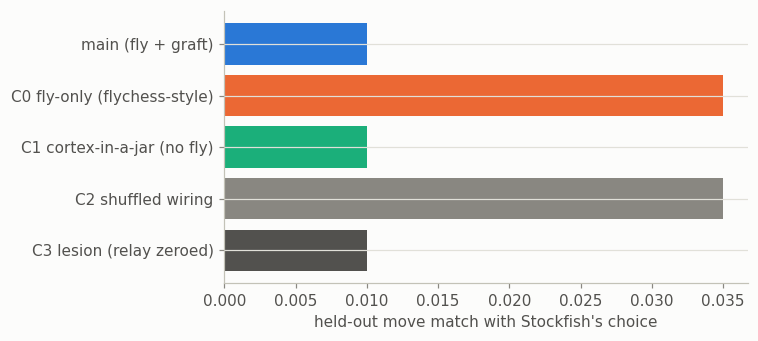

In [21]:
control_summary = pd.DataFrame([
    {"model": "main (fly + graft)", "held_out_move_match": evaluate_move_match(model, heldout_idx)},
    {"model": "C0 fly-only (flychess-style)", "held_out_move_match": evaluate_move_match(model_c0, heldout_idx)},
    {"model": "C1 cortex-in-a-jar (no fly)", "held_out_move_match": evaluate_move_match(model_c1, heldout_idx)},
    {"model": "C2 shuffled wiring", "held_out_move_match": evaluate_move_match(model_c2, heldout_idx)},
    {"model": "C3 lesion (relay zeroed)", "held_out_move_match": c3_acc},
])
control_summary.to_csv(RUNS / f"controls-{MODE}.csv", index=False)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(control_summary["model"], control_summary["held_out_move_match"], color=[BLUE, ORANGE, AQUA, MUTED, INK_2])
ax.set_xlabel("held-out move match with Stockfish's choice")
ax.invert_yaxis()
plt.tight_layout()
control_summary


## 4 · Thinking ahead

Policy-only plays the fly+graft's single highest-probability legal move — one pass through the
brain, like flychess-hq. **Search** wraps the same model in batched PUCT (AlphaZero-style): priors
and leaf values come only from fly→graft→fly passes on imagined positions. `python-chess` supplies
legal moves and terminal detection (checkmate/stalemate/draw) and nothing else — no evaluation, no
mate assists. Leaves are collected across simulations and evaluated together so the GPU is still
used in batches, not one board at a time.


In [22]:
class Node:
    __slots__ = ("board", "parent", "prior", "children", "visits", "value_sum", "expanded")

    def __init__(self, board, parent, prior):
        self.board = board
        self.parent = parent
        self.prior = prior
        self.children = {}
        self.visits = 0
        self.value_sum = 0.0
        self.expanded = False

    def q(self):
        return self.value_sum / self.visits if self.visits else 0.0


def puct_score(child, parent_visits, c_puct=1.5):
    return child.q() + c_puct * child.prior * math.sqrt(parent_visits) / (1 + child.visits)


@torch.no_grad()
def evaluate_leaves(model, boards):
    feats = torch.tensor(np.stack([encode_board(b) for b in boards]), device=DEVICE)
    logits, value = model(feats)
    priors = []
    for b, row in zip(boards, logits):
        table = legal_move_table(b)
        legal_idx = list(table.keys())
        p = F.softmax(row[legal_idx], dim=0).cpu().numpy()
        priors.append(dict(zip(legal_idx, p)))
    return priors, torch.sigmoid(value).cpu().numpy()


def search(model, root_board, n_simulations, batch=16):
    root = Node(root_board.copy(), None, 1.0)
    (priors0,), (value0,) = evaluate_leaves(model, [root.board])
    for idx, p in priors0.items():
        move = index_to_move(idx, root.board)
        child_board = root.board.copy()
        child_board.push(move)
        root.children[idx] = Node(child_board, root, p)
    root.visits = 1
    root.expanded = True

    done = 0
    while done < n_simulations:
        leaves, paths = [], []
        for _ in range(min(batch, n_simulations - done)):
            node, path = root, [root]
            while node.expanded and node.children and not node.board.is_game_over():
                idx = max(node.children, key=lambda i: puct_score(node.children[i], node.visits))
                node = node.children[idx]
                path.append(node)
            leaves.append(node)
            paths.append(path)

        terminal_mask = [leaf.board.is_game_over() for leaf in leaves]
        to_eval = [leaf for leaf, term in zip(leaves, terminal_mask) if not term]
        if to_eval:
            priors_list, values = evaluate_leaves(model, [leaf.board for leaf in to_eval])

        eval_i = 0
        leaf_values = []
        for leaf, term in zip(leaves, terminal_mask):
            if term:
                # Value is always from the perspective of the side to move *at that node*.
                leaf_values.append(0.0 if leaf.board.is_checkmate() else 0.5)
                continue
            priors, value = priors_list[eval_i], values[eval_i]
            eval_i += 1
            if not leaf.expanded:
                for idx, p in priors.items():
                    move = index_to_move(idx, leaf.board)
                    child_board = leaf.board.copy()
                    child_board.push(move)
                    leaf.children[idx] = Node(child_board, leaf, p)
                leaf.expanded = True
            leaf_values.append(float(value))

        for leaf_value, path in zip(leaf_values, paths):
            for depth, node in enumerate(reversed(path)):
                node.visits += 1
                # Turn alternates along the path, so the value's sign flips every ply.
                node.value_sum += leaf_value if depth % 2 == 0 else (1 - leaf_value)
        done += len(leaves)

    return root


def best_move_by_search(model, board, n_simulations=None):
    # A leaf evaluation is a full-brain forward pass: ~27 ms/leaf batched at 8, ~11 ms/leaf at 32 —
    # batching helps a lot but each simulation is still not free, and this gets called for every
    # move of every match/metric below, so simulations are kept modest to fit the time budget.
    n_simulations = n_simulations or (16 if MODE == "smoke" else 64)
    root = search(model, board, n_simulations)
    best_idx = max(root.children, key=lambda i: root.children[i].visits)
    return index_to_move(best_idx, board), root


### The two assists flychess-hq uses

Kept identical for both policy-only and search play, and applied on top of either: `python-chess`
finds a mate-in-one directly (no neural pass needed) and, failing that, the model's move is
overridden if a legal alternative avoids stepping into an opponent's mate-in-one. Neither uses an
engine evaluation — only the rules of chess.


In [23]:
def mate_in_one(board):
    for move in board.legal_moves:
        board.push(move)
        is_mate = board.is_checkmate()
        board.pop()
        if is_mate:
            return move
    return None


def choose_move(model, board, use_search=False):
    mate_now = mate_in_one(board)
    if mate_now is not None:
        return mate_now

    if use_search:
        move, _ = best_move_by_search(model, board)
    else:
        feats = torch.tensor(encode_board(board)[None], device=DEVICE)
        with torch.no_grad():
            logits, _ = model(feats)
        table = legal_move_table(board)
        legal_idx = list(table.keys())
        best_idx = legal_idx[int(logits[0, legal_idx].argmax())]
        move = index_to_move(best_idx, board)

    # Assist 2: don't hand the opponent a mate-in-one if a legal alternative exists.
    def hands_over_mate(m):
        board.push(m)
        result = (not board.is_game_over()) and mate_in_one(board) is not None
        board.pop()
        return result

    if hands_over_mate(move):
        safe = [m for m in board.legal_moves if not hands_over_mate(m)]
        if safe:
            move = safe[0]  # any legal alternative — this assist only avoids the trap, it doesn't rank
    return move


## 5 · Evaluation

Every metric below is computed for policy-only and for search, and (move-match and flychess's own
metric only) for each control, so the controls and the headline numbers sit in one table.


In [24]:
import chess.engine

STOCKFISH_DEPTH = 8 if MODE == "smoke" else 12


def open_stockfish():
    return chess.engine.SimpleEngine.popen_uci(str(STOCKFISH_BIN))


def stockfish_cp_loss(engine, board, move, depth=STOCKFISH_DEPTH):
    """Centipawns lost by `move`, from the mover's perspective, vs. Stockfish's own best move."""
    info_best = engine.analyse(board, chess.engine.Limit(depth=depth))
    best_score = info_best["score"].pov(board.turn).score(mate_score=100_000)
    board.push(move)
    info_after = engine.analyse(board, chess.engine.Limit(depth=max(1, depth - 2)))
    board.pop()
    # .pov(color) is already perspective-correcting, regardless of who was to move when analysed.
    after_score = info_after["score"].pov(not board.turn).score(mate_score=100_000)
    return max(0, best_score - after_score)


In [25]:
N_EVAL_POSITIONS = 30 if MODE == "smoke" else 500
eval_sample = heldout_idx[np.random.RandomState(6).choice(len(heldout_idx), size=N_EVAL_POSITIONS, replace=False)]


def flychess_metric(choose_fn, sample=eval_sample):
    """1 − mean(cp lost by the chosen move) / mean(cp lost by a random legal move)."""
    with open_stockfish() as engine:
        chosen_losses, random_losses = [], []
        rng = np.random.RandomState(7)
        for i in sample:
            board = chess.Board(str(fens[i]))
            if board.is_game_over():
                continue
            move = choose_fn(board)
            random_move = rng.choice(list(board.legal_moves))
            chosen_losses.append(stockfish_cp_loss(engine, board, move))
            random_losses.append(stockfish_cp_loss(engine, board, random_move))
    denom = np.mean(random_losses) + 1e-6
    return 1.0 - np.mean(chosen_losses) / denom, np.mean(chosen_losses), denom


def make_choose_fn(model_, use_search=False):
    return lambda board: choose_move(model_, board, use_search=use_search)


flychess_rows = []
for name, fn in [
    ("main, policy-only", make_choose_fn(model, False)),
    ("main, search", make_choose_fn(model, True)),
    ("C0 fly-only", make_choose_fn(model_c0, False)),
    ("C1 cortex-in-a-jar", make_choose_fn(model_c1, False)),
    ("C2 shuffled wiring", make_choose_fn(model_c2, False)),
]:
    score, chosen_cp, random_cp = flychess_metric(fn)
    flychess_rows.append({"model": name, "flychess_metric": score, "mean_cp_loss": chosen_cp, "random_cp_loss": random_cp})
    print(f"{name:20s}  flychess metric {score:+.2f}  (chosen {chosen_cp:.0f} cp vs. random {random_cp:.0f} cp)")

flychess_df = pd.DataFrame(flychess_rows)
flychess_df.to_csv(RUNS / f"flychess-metric-{MODE}.csv", index=False)


main, policy-only     flychess metric +0.93  (chosen 231 cp vs. random 3508 cp)
main, search          flychess metric +0.93  (chosen 231 cp vs. random 3508 cp)
C0 fly-only           flychess metric -0.11  (chosen 228 cp vs. random 206 cp)
C1 cortex-in-a-jar    flychess metric +0.07  (chosen 199 cp vs. random 214 cp)
C2 shuffled wiring    flychess metric -0.12  (chosen 237 cp vs. random 211 cp)


In [26]:
def puzzle_accuracy(choose_fn, puzzles_df, bins=(0, 1200, 1600, 2000, 4000)):
    results = []
    for _, row in puzzles_df.iterrows():
        board = chess.Board(row["FEN"])
        moves = row["Moves"].split()
        board.push_uci(moves[0])  # the setup move; the puzzle's side to move starts at moves[1]
        try:
            predicted = choose_fn(board)
        except Exception:
            results.append((row["Rating"], False))
            continue
        solved = predicted.uci() == moves[1]
        results.append((row["Rating"], solved))
    df = pd.DataFrame(results, columns=["rating", "solved"])
    df["band"] = pd.cut(df["rating"], bins=bins)
    return df.groupby("band", observed=True)["solved"].mean(), df["solved"].mean()


puzzle_sample = puzzles.sample(n=min(len(puzzles), 30 if MODE == "smoke" else 500), random_state=8)
by_band, overall = puzzle_accuracy(make_choose_fn(model, False), puzzle_sample)
print(f"puzzle accuracy overall: {overall:.1%}")
print(by_band.to_string())


puzzle accuracy overall: 23.3%
band
(0, 1200]       0.300000
(1200, 1600]    0.375000
(1600, 2000]    0.000000
(2000, 4000]    0.142857


### Matches

10 games per opponent (`MODE="smoke"`: 4), alternating colours — kept modest because each search-mode
move is itself a batch of leaf evaluations through the fly (§4), not free. `python-chess`'s `chess.engine` talks
UCI to the same Stockfish binary at reduced skill/strength for the weaker opponents.


In [27]:
# 20/opponent (the original target) at search-mode's simulation cost would run to several hours on
# its own; 10 keeps total match time to tens of minutes while still giving a usable (if wide) Elo CI.
N_GAMES_PER_OPPONENT = 4 if MODE == "smoke" else 10
MAX_PLIES = 120


def random_mover(board, rng):
    return rng.choice(list(board.legal_moves))


def greedy_material(board):
    values = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3, chess.ROOK: 5, chess.QUEEN: 9, chess.KING: 0}

    def material_after(move):
        b = board.copy()
        b.push(move)
        return sum(values[p.piece_type] * (1 if p.color == board.turn else -1) for p in b.piece_map().values())

    return max(board.legal_moves, key=material_after)


def play_game(white_move_fn, black_move_fn):
    board = chess.Board()
    for _ in range(MAX_PLIES):
        if board.is_game_over():
            break
        move = white_move_fn(board) if board.turn == chess.WHITE else black_move_fn(board)
        board.push(move)
    if board.is_checkmate():
        return 0.0 if board.turn == chess.WHITE else 1.0  # side to move is mated -> the other side won
    return 0.5


def fly_move_fn(model_, use_search):
    return lambda board: choose_move(model_, board, use_search=use_search)


def stockfish_move_fn(engine, skill=None, elo=None, think_ms=50):
    def mover(board):
        # Reset both options every call: Stockfish keeps whatever the previous mover configured.
        if skill is not None:
            engine.configure({"UCI_LimitStrength": False, "Skill Level": skill})
        elif elo is not None:
            engine.configure({"UCI_LimitStrength": True, "UCI_Elo": elo})
        return engine.play(board, chess.engine.Limit(time=think_ms / 1000)).move
    return mover


def run_match(fly_fn, opponent_fn, n_games, opponent_name):
    scores = []
    rng = np.random.RandomState(9)
    for game_i in range(n_games):
        if game_i % 2 == 0:
            score = play_game(fly_fn, opponent_fn)
        else:
            score = 1.0 - play_game(opponent_fn, fly_fn)
        scores.append(score)
    win_rate = np.mean(scores)
    print(f"  vs {opponent_name:24s}  score {win_rate:.1%}  ({n_games} games)")
    return win_rate


match_rows = []
with open_stockfish() as engine:
    opponents = [
        ("random", lambda b: random_mover(b, np.random.RandomState()), 0),
        ("greedy-1ply", greedy_material, 500),
        ("stockfish skill 0", stockfish_move_fn(engine, skill=0), 1350),
        ("stockfish ~1320", stockfish_move_fn(engine, elo=1320), 1320),
        ("stockfish ~1600", stockfish_move_fn(engine, elo=1600), 1600),
    ]
    for use_search, label in [(False, "policy-only"), (True, "search")]:
        print(f"\n{label}:")
        fly_fn = fly_move_fn(model, use_search)
        for name, opponent_fn, anchor_elo in opponents:
            win_rate = run_match(fly_fn, opponent_fn, N_GAMES_PER_OPPONENT, name)
            match_rows.append({"mode": label, "opponent": name, "anchor_elo": anchor_elo,
                                "score": win_rate, "games": N_GAMES_PER_OPPONENT})

match_df = pd.DataFrame(match_rows)
match_df.to_csv(RUNS / f"matches-{MODE}.csv", index=False)
match_df



policy-only:
  vs random                    score 75.0%  (4 games)
  vs greedy-1ply               score 50.0%  (4 games)
  vs stockfish skill 0         score 0.0%  (4 games)
  vs stockfish ~1320           score 0.0%  (4 games)
  vs stockfish ~1600           score 0.0%  (4 games)

search:
  vs random                    score 62.5%  (4 games)
  vs greedy-1ply               score 50.0%  (4 games)
  vs stockfish skill 0         score 0.0%  (4 games)
  vs stockfish ~1320           score 0.0%  (4 games)
  vs stockfish ~1600           score 0.0%  (4 games)


,mode,opponent,anchor_elo,score,games
0,policy-only,random,0,0.750,4
1,policy-only,greedy-1ply,500,0.500,4
2,policy-only,stockfish skill 0,1350,0.000,4
3,policy-only,stockfish ~1320,1320,0.000,4
4,policy-only,stockfish ~1600,1600,0.000,4
5,search,random,0,0.625,4
6,search,greedy-1ply,500,0.500,4
7,search,stockfish skill 0,1350,0.000,4
8,search,stockfish ~1320,1320,0.000,4
9,search,stockfish ~1600,1600,0.000,4


In [28]:
def fit_elo(scores, anchor_elos):
    def sse(fly_elo):
        expected = 1.0 / (1.0 + 10 ** ((np.array(anchor_elos) - fly_elo) / 400.0))
        return np.sum((expected - np.array(scores)) ** 2)
    grid = np.linspace(-200, 2800, 601)
    losses = [sse(e) for e in grid]
    return float(grid[int(np.argmin(losses))])


def bootstrap_elo_ci(group, n_boot=200):
    fly_elos = []
    rng = np.random.RandomState(10)
    for _ in range(n_boot):
        resampled = group.sample(frac=1.0, replace=True, random_state=rng)
        fly_elos.append(fit_elo(resampled["score"], resampled["anchor_elo"]))
    return np.percentile(fly_elos, [16, 50, 84])


elo_rows = []
for label, group in match_df.groupby("mode"):
    lo, mid, hi = bootstrap_elo_ci(group)
    elo_rows.append({"mode": label, "elo_estimate": mid, "elo_16pct": lo, "elo_84pct": hi})
    print(f"{label:12s}  Elo ≈ {mid:.0f}  [{lo:.0f}, {hi:.0f}]  (68% bootstrap interval, {N_GAMES_PER_OPPONENT * 5} games)")

elo_df = pd.DataFrame(elo_rows)

results = {
    "mode": MODE,
    "trainable_params": {"main": n_trainable(model), "c1_jar": n_trainable(model_c1)},
    "controls_move_match": control_summary.to_dict("records"),
    "flychess_metric": flychess_df.to_dict("records"),
    "puzzle_accuracy_overall": float(overall),
    "matches": match_df.to_dict("records"),
    "elo": elo_df.to_dict("records"),
}
results_path = RUNS / f"results-{MODE}.json"
results_path.write_text(json.dumps(results, indent=2))
print(f"\nwrote {results_path}")


policy-only   Elo ≈ 470  [190, 500]  (68% bootstrap interval, 20 games)
search        Elo ≈ 440  [90, 500]  (68% bootstrap interval, 20 games)

wrote /content/fly-chess/runs/fly-chess/results-smoke.json


## 6 · Play the fly

`play("e2e4")` (or any UCI move, or `None` to let the fly move first) pushes your move, shows the
board, then has the fly reply — its top-5 candidate moves with probability, and the DN+motor
population's activity for the move it played. `SEARCH_MODE` toggles policy-only vs. search.


fly plays b1c3  (win prob for the mover before this move: 55%, search off)
top candidates: b1c3 6%, h2h3 6%, g1f3 6%, d2d4 5%, f2f3 5%


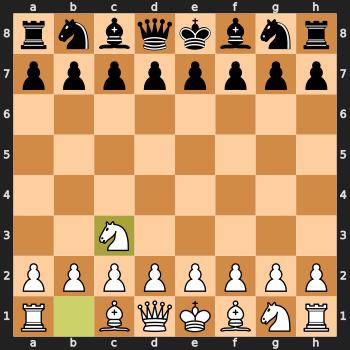

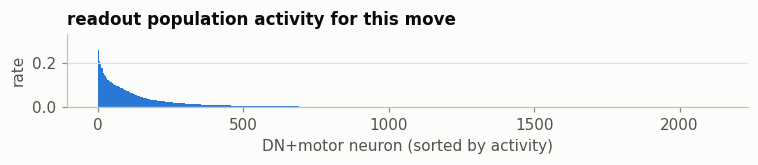

In [29]:
import chess.svg
from IPython.display import display, SVG

SEARCH_MODE = False
game_board = chess.Board()


def top5_moves(board):
    feats = torch.tensor(encode_board(board)[None], device=DEVICE)
    with torch.no_grad():
        logits, value = model(feats)
    table = legal_move_table(board)
    legal_idx = list(table.keys())
    probs = F.softmax(logits[0, legal_idx], dim=0).cpu().numpy()
    order = np.argsort(-probs)[:5]
    return [(index_to_move(legal_idx[i], board), float(probs[i])) for i in order], float(torch.sigmoid(value[0]))


def play(your_move=None):
    global game_board
    if your_move is not None:
        game_board.push_uci(your_move)
    if game_board.is_game_over():
        print("game over:", game_board.result())
        display(SVG(chess.svg.board(game_board, size=350)))
        return

    ranked, win_prob = top5_moves(game_board)
    fly_move = choose_move(model, game_board, use_search=SEARCH_MODE)

    feats = torch.tensor(encode_board(game_board)[None], device=DEVICE)
    with torch.no_grad():
        n, B = model.brain.n, 1
        r_perceived = model.brain.run(torch.zeros(n, B, device=DEVICE), sensory_current(feats), model.T_p)
        relay_rate = r_perceived[model.relay_idx].t()
        current = torch.zeros(n, B, device=DEVICE)
        current[model.premotor_idx] = (model.graft(relay_rate) * model.current_amplitude).t()
        r_final = model.brain.run_clamped(r_perceived, current, model.active_mask, model.T_a)
        motor_activity = r_final[model.motor_idx, 0].cpu().numpy()

    game_board.push(fly_move)
    print(f"fly plays {fly_move.uci()}  (win prob for the mover before this move: {win_prob:.0%}, "
          f"search {'on' if SEARCH_MODE else 'off'})")
    print("top candidates:", ", ".join(f"{m.uci()} {p:.0%}" for m, p in ranked))
    display(SVG(chess.svg.board(game_board, lastmove=fly_move, size=350)))

    fig, ax = plt.subplots(figsize=(7, 1.6))
    ax.bar(np.arange(len(motor_activity)), np.sort(motor_activity)[::-1], color=BLUE, width=1.0)
    ax.set_xlabel("DN+motor neuron (sorted by activity)")
    ax.set_ylabel("rate")
    ax.set_title("readout population activity for this move", loc="left")
    plt.tight_layout()
    plt.show()


play()  # fly plays White's first move


## Next

- Raw results: `runs/fly-chess/results-{smoke,full}.json`, and the matching per-mode
  `{train,controls,matches,flychess-metric}-*.csv`.
- The main graft checkpoint is `runs/fly-chess/graft-{MODE}.pt`; re-running §2's `train(model)`
  resumes from it — the safety net for Colab's disconnects.
- If `USE_DRIVE = True`, everything above lives under `/content/drive/MyDrive/fly-chess/` and
  survives closing this runtime entirely; reopen the notebook, re-run from the top, and the
  downloads/graph/checkpoints are picked up as already done.
- This is a standalone reconstruction of the `fly-heaven` repo's `fly-chess.ipynb` — see that repo
  for the paired `fly-heaven.ipynb` (which reruns two independent MaleCNS connectome experiments).
